# Booking Funnel Analysis (NYC vs Dubai)

**Business Question:** *"Where does the OTA booking funnel leak for Dubai vs NYC — and what market-level factors cause it?"*

| # | Source | Signal | Used For |
|---|--------|--------|----------|
| 1 | Google Places API — Dubai | Hotel listings, ratings, reviews, price levels | Destination market |
| 2 | Google Places API — NYC | Same data for origin city | Comparison baseline |

### Why This Matters
NYC travelers booking Dubai hotels face:
- **Unfamiliarity** with brands (Rotana? Jumeirah? vs Marriott, Hilton)
- **Sticker shock** (Dubai luxury pricing >> NYC mid-range)
- **Trust gap** (fewer reviews from US travelers)
- **Choice architecture** (fewer options but more extreme price spread)

### Pipeline
1. **Ingest** raw hotel data (Google Places API or synthetic fallback)
2. **Preprocess** via `prepare_funnel_data()` — add price tiers, rating tiers, visibility scores
3. **Compare** markets side-by-side on supply, pricing, quality, engagement
4. **Simulate** 5-stage booking funnels per market
5. **Diagnose** drop-off differences and generate OTA recommendations


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from config.settings import (
    GOOGLE_CLOUD_API_KEY, DATA_RAW, DATA_PROCESSED,
    FIGURES_DIR, REPORTS_DIR,
)
from src.data_collection.google_places import (
    fetch_both_markets, fetch_dubai_hotels, fetch_nyc_hotels,
    save_places_data, load_places_data
)
from src.analysis.funnel_analyzer import (
    prepare_funnel_data, compare_markets,
    simulate_booking_funnel, get_funnel_summary,
    diagnose_dropoff, analyze_price_distribution,
    analyze_rating_review_gap,
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 120

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(DATA_PROCESSED / "booking_funnel").mkdir(parents=True, exist_ok=True)

COLORS = {"Dubai": "#E53935", "NYC": "#1E88E5"}

print("Setup complete")


Setup complete


In [3]:
# ═══════════════════════════════════════════════════════════
# 1. DATA INGESTION
# ═══════════════════════════════════════════════════════════
from scripts.generate_seeds import generate_hotels
hotels_raw = None

if GOOGLE_CLOUD_API_KEY:
    print(f"Google Cloud API key found: {GOOGLE_CLOUD_API_KEY[:8]}...")
    try:
        dubai_raw = load_places_data("Dubai")
        nyc_raw = load_places_data("NYC")
        hotels_raw = pd.concat([dubai_raw, nyc_raw], ignore_index=True)
        print(f"Loaded saved data: {len(hotels_raw)} hotels")
    except FileNotFoundError:
        print("No saved data — fetching from Google Places API...")
        hotels_raw = fetch_both_markets(fetch_details=True)
        if not hotels_raw.empty:
            for market in ["Dubai", "NYC"]:
                save_places_data(hotels_raw[hotels_raw["MARKET"] == market], market)
        else:
            hotels_raw = None

if hotels_raw is None:
    print("No GOOGLE_CLOUD_API_KEY -> synthetic hotel data")
    hotels_raw = generate_hotels()
    for market in ["Dubai", "NYC"]:
        save_places_data(hotels_raw[hotels_raw["MARKET"] == market], market)

print(f"\nRaw dataset: {len(hotels_raw)} hotels")
print(hotels_raw.groupby("MARKET").size())


Google Cloud API key found: AIzaSyCN...
Loaded saved data: 202 hotels

Raw dataset: 202 hotels
MARKET
Dubai     96
NYC      106
dtype: int64


In [4]:
# ═══════════════════════════════════════════════════════════
# 2. PREPROCESSING — prepare_funnel_data()
# ═══════════════════════════════════════════════════════════

hotels = prepare_funnel_data(hotels_raw)

print(f"\nEnriched columns added:")
print(f"  PRICE_TIER:       {hotels['PRICE_TIER'].value_counts().to_dict()}")
print(f"  RATING_TIER:      {hotels['RATING_TIER'].value_counts().to_dict()}")
print(f"  VISIBILITY_SCORE: mean={hotels['VISIBILITY_SCORE'].mean():.1f}, "
      f"range=[{hotels['VISIBILITY_SCORE'].min():.1f}, {hotels['VISIBILITY_SCORE'].max():.1f}]")
print(f"  IS_BOOKABLE:      {hotels['IS_BOOKABLE'].sum()} / {len(hotels)} "
      f"({hotels['IS_BOOKABLE'].mean():.0%})")

display(hotels.head())


Prepared funnel data: 202 hotels
  Bookable: 200 (99%)

Enriched columns added:
  PRICE_TIER:       {'Unknown': 196, 'Upscale': 4, 'Luxury': 2}
  RATING_TIER:      {'Excellent': 78, 'Good': 68, 'Average': 37, 'Low': 19}
  VISIBILITY_SCORE: mean=54.2, range=[30.2, 97.9]
  IS_BOOKABLE:      200 / 202 (99%)


,PLACE_ID,NAME,MARKET,RATING,TOTAL_RATINGS,PRICE_LEVEL,ADDRESS,LAT,LNG,BUSINESS_STATUS,...,PHONE,NUM_PHOTOS,NUM_REVIEWS_FETCHED,AVG_REVIEW_RATING,REVIEW_TEXTS,OPEN_NOW,PRICE_TIER,RATING_TIER,VISIBILITY_SCORE,IS_BOOKABLE
0,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,4.7,30807,NaN,Dubai - Umm Suqeim Third - Umm Suqeim 3 - Duba...,25.141191,55.185247,OPERATIONAL,...,04 301 7777,10,5,5.0,Staying in a suite at the Burj Al Arab was tru...,NaN,Unknown,Excellent,92.8,True
1,ChIJeckJNj4VXz4RxUqAikFalAU,Atlantis - The Palm,Dubai,4.7,101541,NaN,Crescent Rd - The Palm Jumeirah - Dubai - Unit...,25.130443,55.117150,OPERATIONAL,...,04 426 0000,10,5,4.8,🌟🌟🌟🌟🌟\nAtlantis The Palm meets the King of Lov...,NaN,Unknown,Excellent,97.9,True
2,ChIJ_-wTYzdrXz4RrrhErFCw21o,FIVE Palm Jumeirah Hotel,Dubai,4.7,25103,NaN,No. 1 Palm - The Palm Jumeirah - Dubai - Unite...,25.104330,55.148769,OPERATIONAL,...,04 455 9999,10,5,5.0,I had an amazing stay at **FIVE Palm Jumeirah*...,True,Unknown,Excellent,84.4,True
3,ChIJ9c0WNcoUXz4RmIIVjEG9uqo,One&Only The Palm,Dubai,4.7,3103,NaN,"West Crescent, Palm - نخلة جميرا - Jumeirah - ...",25.099485,55.133463,OPERATIONAL,...,04 440 1010,10,5,5.0,One&Only The Palm is the definition of quiet l...,True,Unknown,Excellent,52.4,True
4,ChIJ8-LpJSNCXz4RSYU8D8qlVl4,Bvlgari Resort Dubai,Dubai,4.6,3870,NaN,Jumeirah Bay Island - جميرا باي - جميرا ٢ - دب...,25.210697,55.236428,OPERATIONAL,...,04 777 5555,10,5,5.0,I had an amazing stay here. everything from th...,NaN,Unknown,Excellent,52.8,True


## Market Comparison — Dubai vs NYC


In [5]:
comparison = compare_markets(hotels)
display(comparison.T)


,0,1
MARKET,Dubai,NYC
TOTAL_LISTINGS,96,106
BOOKABLE_LISTINGS,94,106
BOOKABILITY_RATE,97.9,100.0
AVG_PRICE_LEVEL,NaN,3.33
MEDIAN_PRICE_LEVEL,NaN,3.0
PCT_LUXURY,0.0,1.9
PCT_BUDGET,0.0,0.0
AVG_RATING,4.43,3.97
MEDIAN_RATING,4.6,4.1


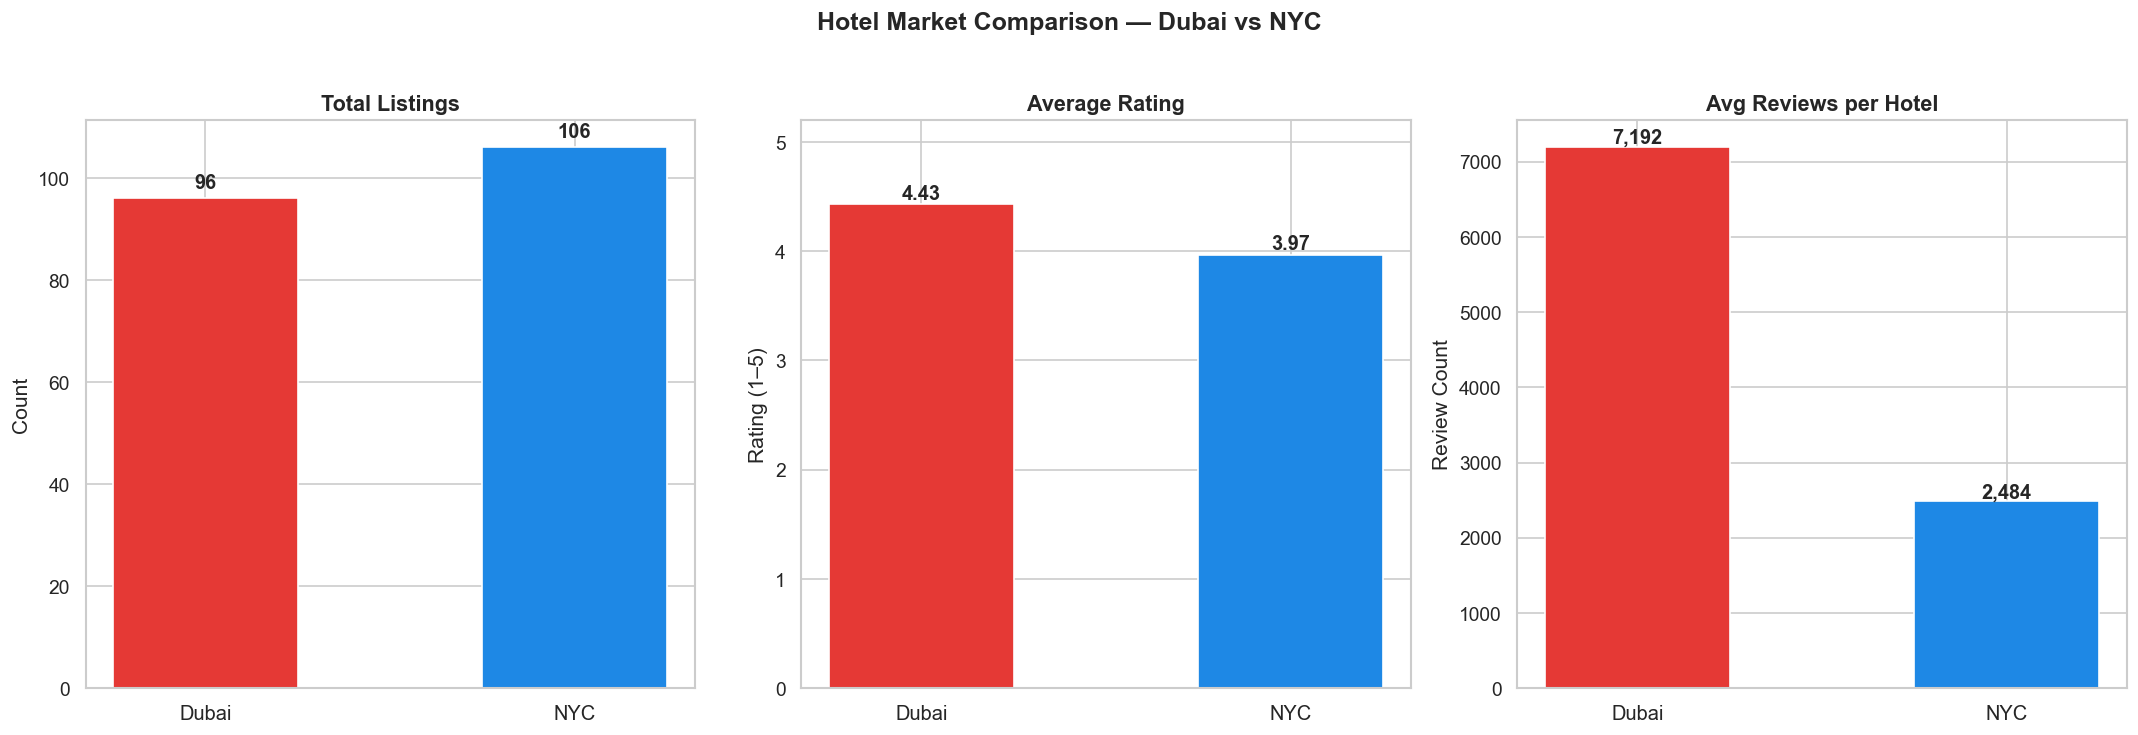

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

markets = comparison["MARKET"].tolist()
x = np.arange(len(markets))

# Panel 1: Total Listings
ax = axes[0]
bars = ax.bar(x, comparison["TOTAL_LISTINGS"], width=0.5,
              color=[COLORS.get(m, "#999") for m in markets], edgecolor="white")
ax.set_title("Total Listings", fontsize=13, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(markets, fontsize=12)
ax.set_ylabel("Count")
for bar, val in zip(bars, comparison["TOTAL_LISTINGS"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(val)), ha="center", fontweight="bold", fontsize=12)

# Panel 2: Avg Rating
ax = axes[1]
bars = ax.bar(x, comparison["AVG_RATING"], width=0.5,
              color=[COLORS.get(m, "#999") for m in markets], edgecolor="white")
ax.set_title("Average Rating", fontsize=13, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(markets, fontsize=12)
ax.set_ylabel("Rating (1–5)"); ax.set_ylim(0, 5.2)
for bar, val in zip(bars, comparison["AVG_RATING"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", fontweight="bold", fontsize=12)

# Panel 3: Avg Reviews Per Hotel
ax = axes[2]
bars = ax.bar(x, comparison["AVG_TOTAL_RATINGS"], width=0.5,
              color=[COLORS.get(m, "#999") for m in markets], edgecolor="white")
ax.set_title("Avg Reviews per Hotel", fontsize=13, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(markets, fontsize=12)
ax.set_ylabel("Review Count")
for bar, val in zip(bars, comparison["AVG_TOTAL_RATINGS"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:,.0f}", ha="center", fontweight="bold", fontsize=12)

plt.suptitle("Hotel Market Comparison — Dubai vs NYC", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m02_market_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Price Tier Analysis


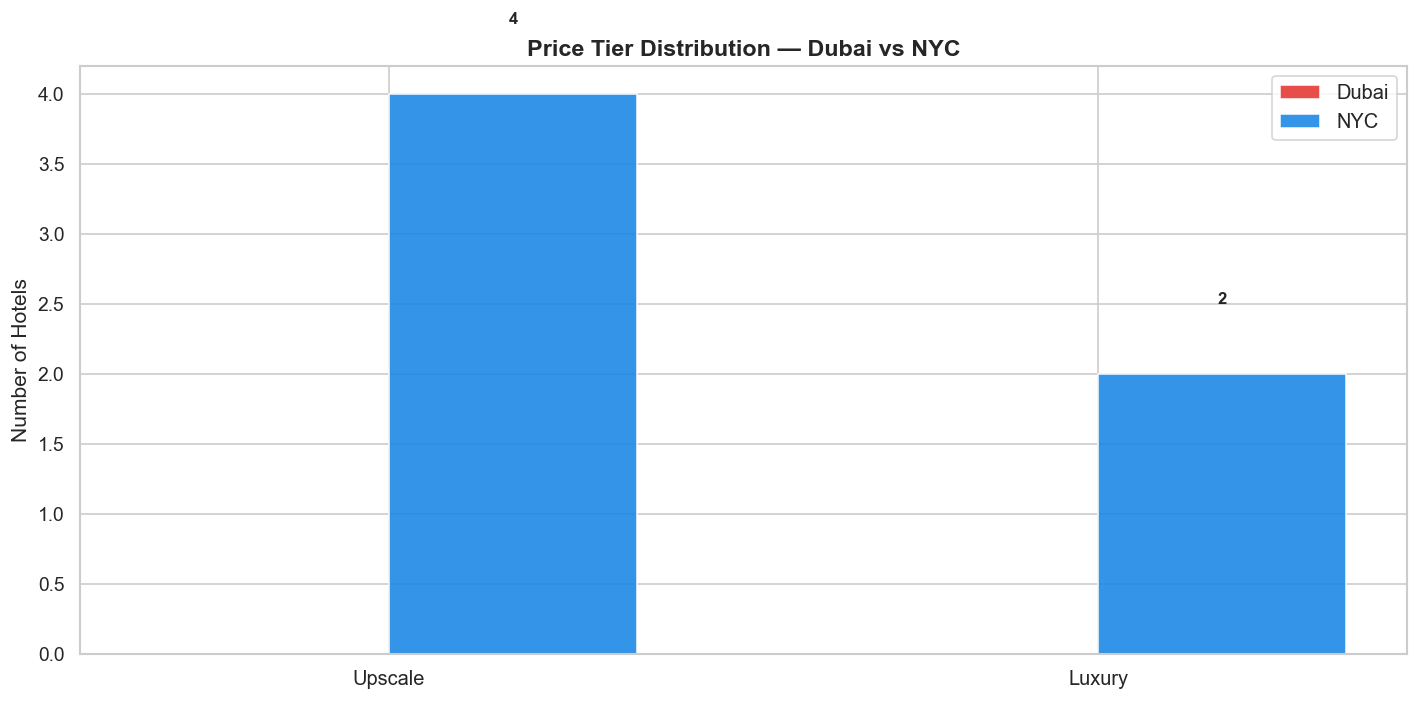

,MARKET,PRICE_TIER,COUNT,PCT_OF_MARKET,AVG_RATING
0,Dubai,Unknown,96,100.0,4.433333
2,NYC,Unknown,100,94.3,3.955000
3,NYC,Upscale,4,3.8,4.225000
1,NYC,Luxury,2,1.9,4.000000


In [7]:
price_dist = analyze_price_distribution(hotels)

tier_order = ["Budget", "Mid-Range", "Upscale", "Luxury"]
available_tiers = [t for t in tier_order if t in price_dist["PRICE_TIER"].values]

fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.35
x = np.arange(len(available_tiers))

for i, market in enumerate(["Dubai", "NYC"]):
    mdata = price_dist[price_dist["MARKET"] == market]
    counts = [mdata.loc[mdata["PRICE_TIER"] == t, "COUNT"].values[0]
              if t in mdata["PRICE_TIER"].values else 0 for t in available_tiers]
    offset = -bar_width/2 + i * bar_width
    bars = ax.bar(x + offset, counts, bar_width, label=market,
                  color=COLORS[market], edgecolor="white", alpha=0.9)
    for bar, val in zip(bars, counts):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(int(val)), ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(available_tiers, fontsize=12)
ax.set_ylabel("Number of Hotels")
ax.set_title("Price Tier Distribution — Dubai vs NYC", fontsize=14, fontweight="bold")
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m02_price_tiers.png", dpi=150, bbox_inches="tight")
plt.show()

display(price_dist[["MARKET", "PRICE_TIER", "COUNT", "PCT_OF_MARKET", "AVG_RATING"]])


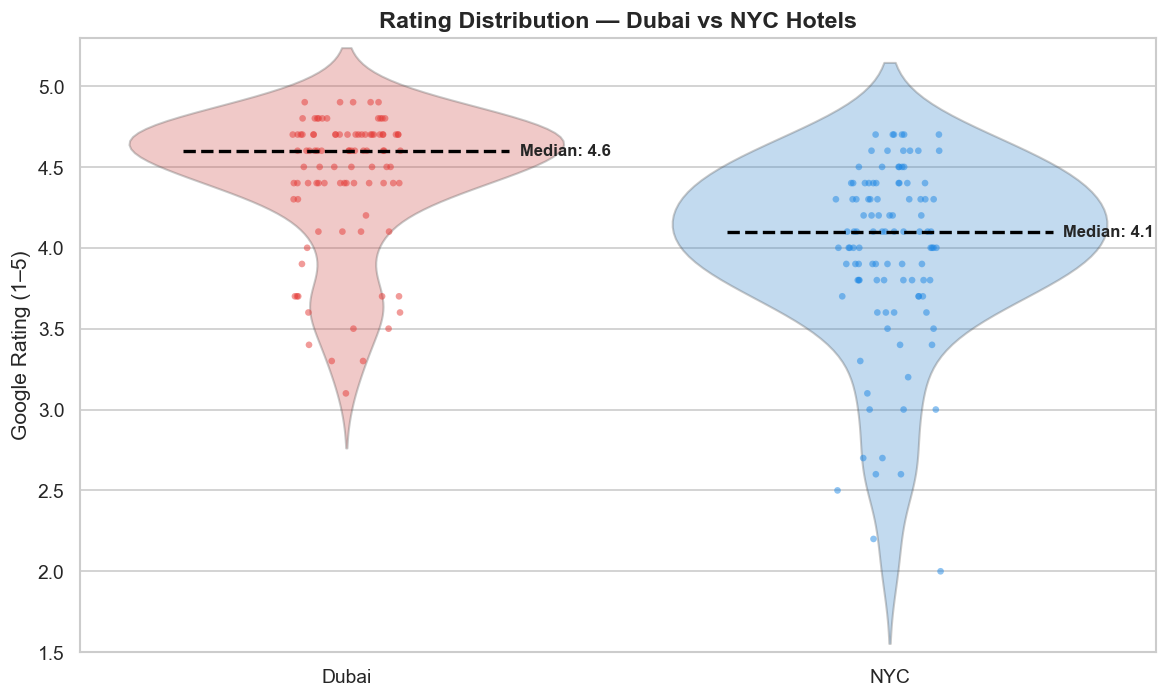

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(data=hotels, x="MARKET", y="RATING", palette=COLORS,
               inner=None, alpha=0.3, ax=ax)
sns.stripplot(data=hotels, x="MARKET", y="RATING", palette=COLORS,
              size=4, alpha=0.5, jitter=True, ax=ax)

for i, market in enumerate(["Dubai", "NYC"]):
    median_val = hotels[hotels["MARKET"] == market]["RATING"].median()
    ax.hlines(median_val, i - 0.3, i + 0.3, colors="black", linewidth=2, linestyle="--", zorder=10)
    ax.text(i + 0.32, median_val, f"Median: {median_val:.1f}", fontsize=10, fontweight="bold", va="center")

ax.set_title("Rating Distribution — Dubai vs NYC Hotels", fontsize=14, fontweight="bold")
ax.set_ylabel("Google Rating (1–5)")
ax.set_xlabel("")
ax.set_ylim(1.5, 5.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m02_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## Trust Quadrant — Rating vs Review Volume


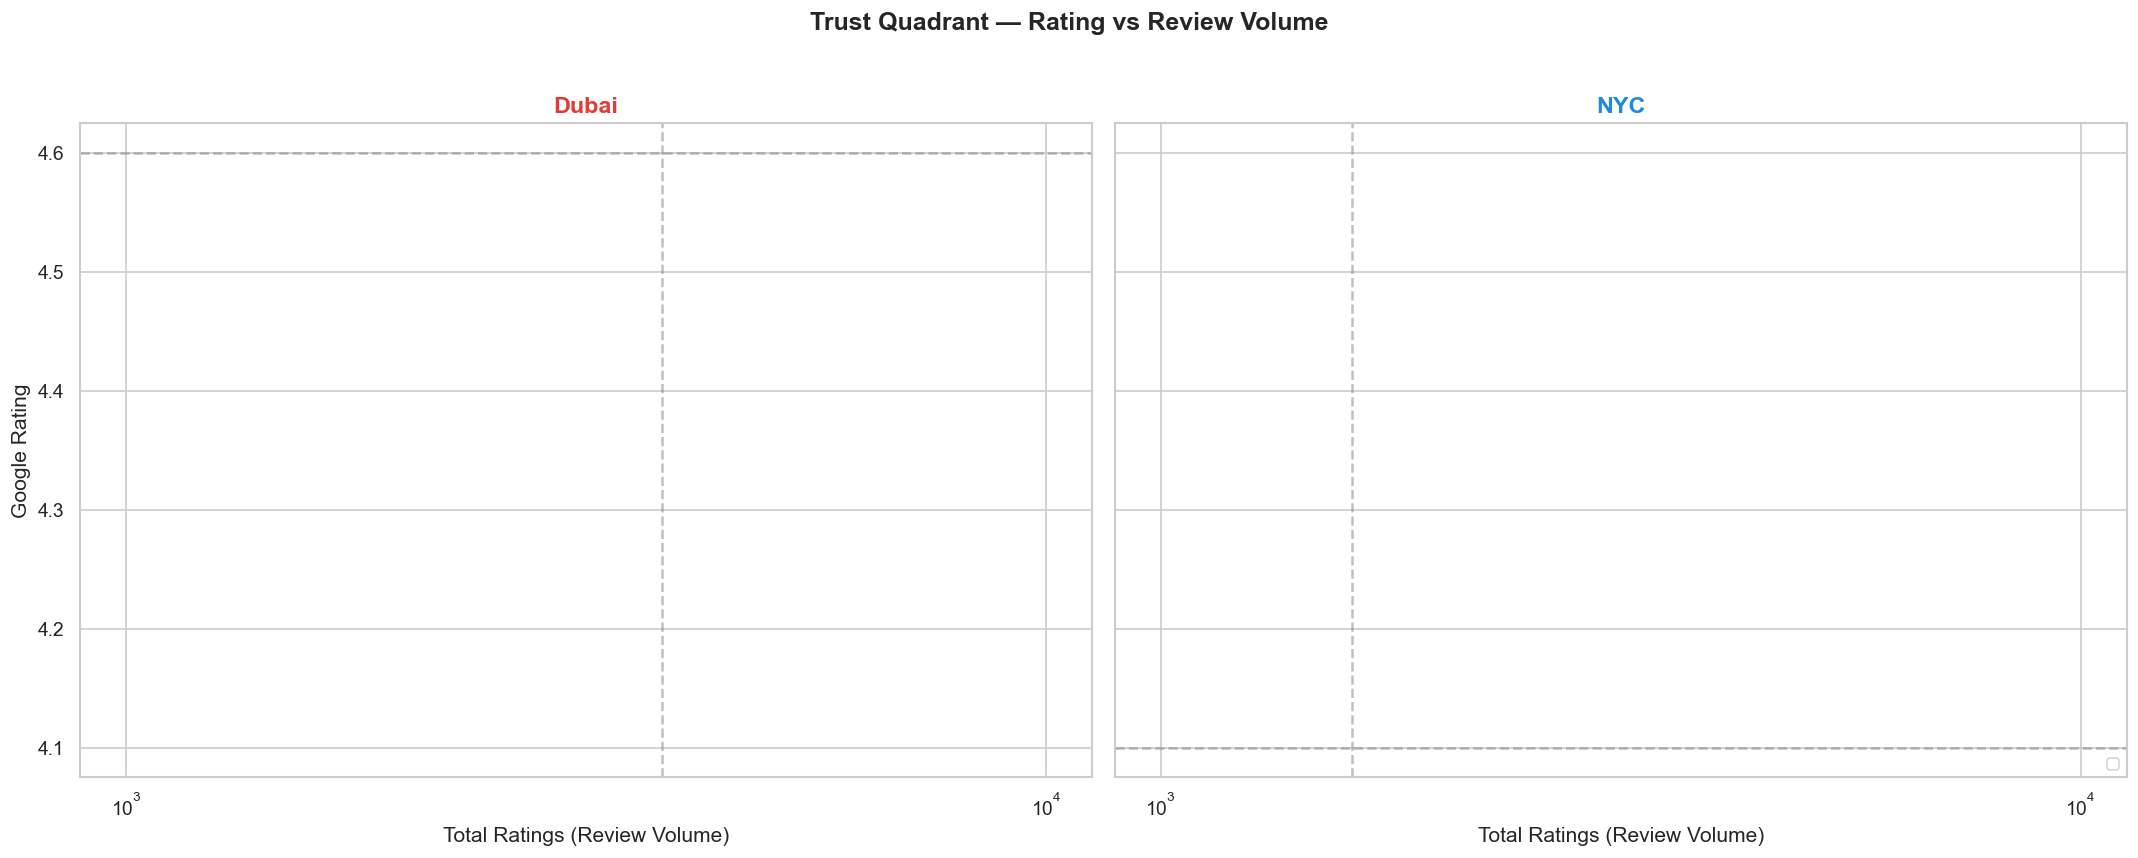

,MARKET,TRUST_QUADRANT,COUNT,AVG_RATING
0,Dubai,Hidden Gem,14,4.692857
1,Dubai,Known but Risky,9,4.366667
2,Dubai,Low Signal,34,4.020588
3,Dubai,Star Performer,39,4.715385
4,NYC,Hidden Gem,28,4.464286
5,NYC,Known but Risky,26,3.696154
6,NYC,Low Signal,25,3.368000
7,NYC,Star Performer,27,4.262963


In [9]:
hotels_trust, quad_summary = analyze_rating_review_gap(hotels)

quadrant_colors = {
    "⭐ Star Performer": "#4CAF50",
    "🔍 Hidden Gem": "#FF9800",
    "⚠️ Known but Risky": "#F44336",
    "❌ Low Signal": "#9E9E9E",
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for idx, market in enumerate(["Dubai", "NYC"]):
    ax = axes[idx]
    mdf = hotels_trust[hotels_trust["MARKET"] == market]

    for quad, color in quadrant_colors.items():
        qdf = mdf[mdf["TRUST_QUADRANT"] == quad]
        if len(qdf) > 0:
            ax.scatter(qdf["TOTAL_RATINGS"], qdf["RATING"],
                       c=color, label=quad, s=50, alpha=0.7, edgecolors="white", linewidth=0.5)

    rating_med = mdf["RATING"].median()
    reviews_med = mdf["TOTAL_RATINGS"].median()
    ax.axhline(rating_med, color="gray", ls="--", alpha=0.5)
    ax.axvline(reviews_med, color="gray", ls="--", alpha=0.5)

    ax.set_title(f"{market}", fontsize=14, fontweight="bold", color=COLORS[market])
    ax.set_xlabel("Total Ratings (Review Volume)")
    if idx == 0:
        ax.set_ylabel("Google Rating")
    ax.set_xscale("log")
    if idx == 1:
        ax.legend(loc="lower right", fontsize=9)

plt.suptitle("Trust Quadrant — Rating vs Review Volume", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m02_trust_quadrant.png", dpi=150, bbox_inches="tight")
plt.show()

display(quad_summary)


## Booking Funnel Simulation

5-stage funnel: **Search → View → Compare → Intent → Book**

Each stage's conversion is modulated by hotel-level features:
- View: driven by visibility score (photos, name recognition)
- Compare: driven by rating quality
- Intent: driven by price competitiveness
- Book: driven by review volume (trust signals)


In [10]:
dubai_funnel = simulate_booking_funnel(hotels, "Dubai")
nyc_funnel = simulate_booking_funnel(hotels, "NYC")

dubai_summary = get_funnel_summary(dubai_funnel, "Dubai")
nyc_summary = get_funnel_summary(nyc_funnel, "NYC")

print("Dubai Funnel:")
display(dubai_summary)
print("\nNYC Funnel:")
display(nyc_summary)

print(f"\nOverall Search→Book conversion:")
print(f"  Dubai: {dubai_summary.iloc[-1]['OVERALL_CONVERSION_PCT']:.2f}%")
print(f"  NYC:   {nyc_summary.iloc[-1]['OVERALL_CONVERSION_PCT']:.2f}%")


Dubai Funnel:


,STAGE,VISITORS,DROP_OFF,DROP_OFF_PCT,OVERALL_CONVERSION_PCT,MARKET
0,1. Search,10000,NaN,NaN,100.00,Dubai
1,2. View Listing,6334,3666.0,36.7,63.34,Dubai
2,3. Compare,2475,3859.0,60.9,24.75,Dubai
3,4. Intent (Select Dates),790,1685.0,68.1,7.90,Dubai
4,5. Book,548,242.0,30.6,5.48,Dubai



NYC Funnel:


,STAGE,VISITORS,DROP_OFF,DROP_OFF_PCT,OVERALL_CONVERSION_PCT,MARKET
0,1. Search,10000,NaN,NaN,100.00,NYC
1,2. View Listing,4403,5597.0,56.0,44.03,NYC
2,3. Compare,2163,2240.0,50.9,21.63,NYC
3,4. Intent (Select Dates),536,1627.0,75.2,5.36,NYC
4,5. Book,254,282.0,52.6,2.54,NYC



Overall Search→Book conversion:
  Dubai: 5.48%
  NYC:   2.54%


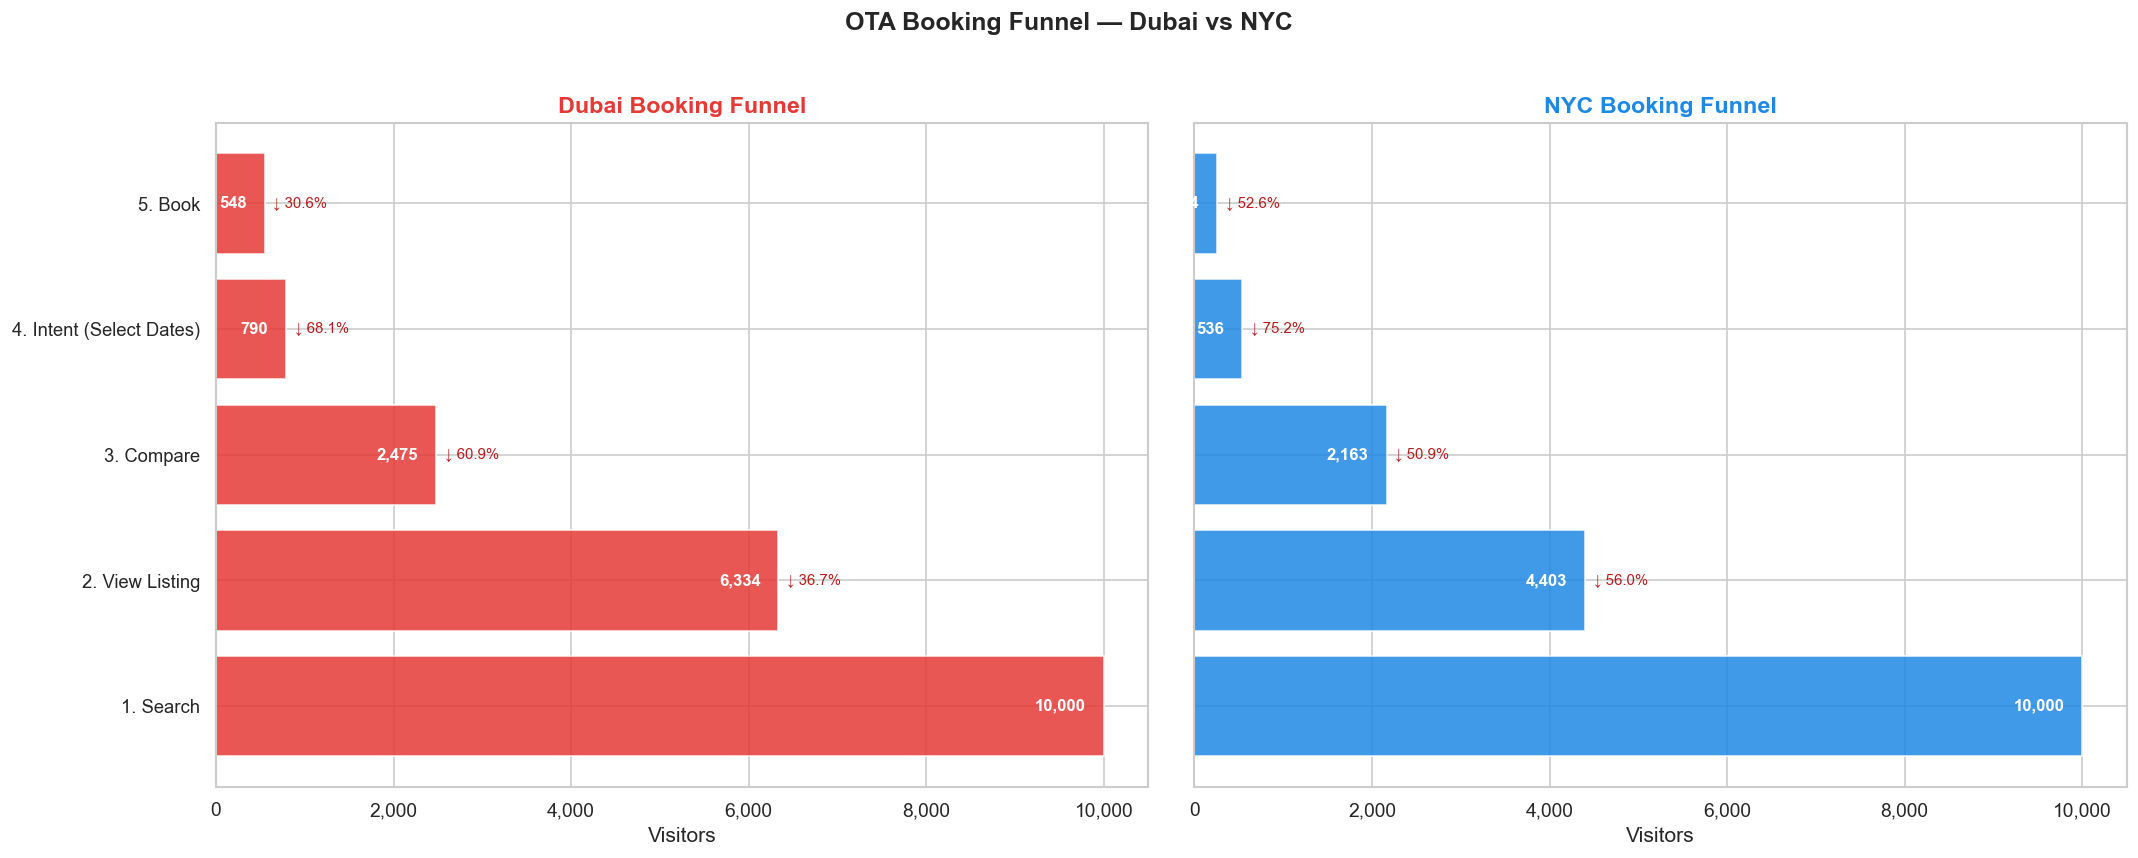

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for idx, (summary, market) in enumerate([(dubai_summary, "Dubai"), (nyc_summary, "NYC")]):
    ax = axes[idx]
    stages = summary["STAGE"].tolist()
    visitors = summary["VISITORS"].tolist()
    dropoffs = summary["DROP_OFF_PCT"].tolist()

    y_pos = np.arange(len(stages))
    bars = ax.barh(y_pos, visitors, color=COLORS[market], alpha=0.85, edgecolor="white")

    max_v = max(visitors)
    for j, (bar, v, d) in enumerate(zip(bars, visitors, dropoffs)):
        ax.text(bar.get_width() - max_v * 0.02, bar.get_y() + bar.get_height()/2,
                f"{v:,.0f}", ha="right", va="center", fontsize=10, fontweight="bold", color="white")
        if not np.isnan(d) and d > 0:
            ax.text(bar.get_width() + max_v * 0.01, bar.get_y() + bar.get_height()/2,
                    f"↓ {d:.1f}%", ha="left", va="center", fontsize=9, color="#B71C1C")

    ax.set_yticks(y_pos); ax.set_yticklabels(stages, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlabel("Visitors")
    ax.set_title(f"{market} Booking Funnel", fontsize=14, fontweight="bold", color=COLORS[market])
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle("OTA Booking Funnel — Dubai vs NYC", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m02_funnel_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


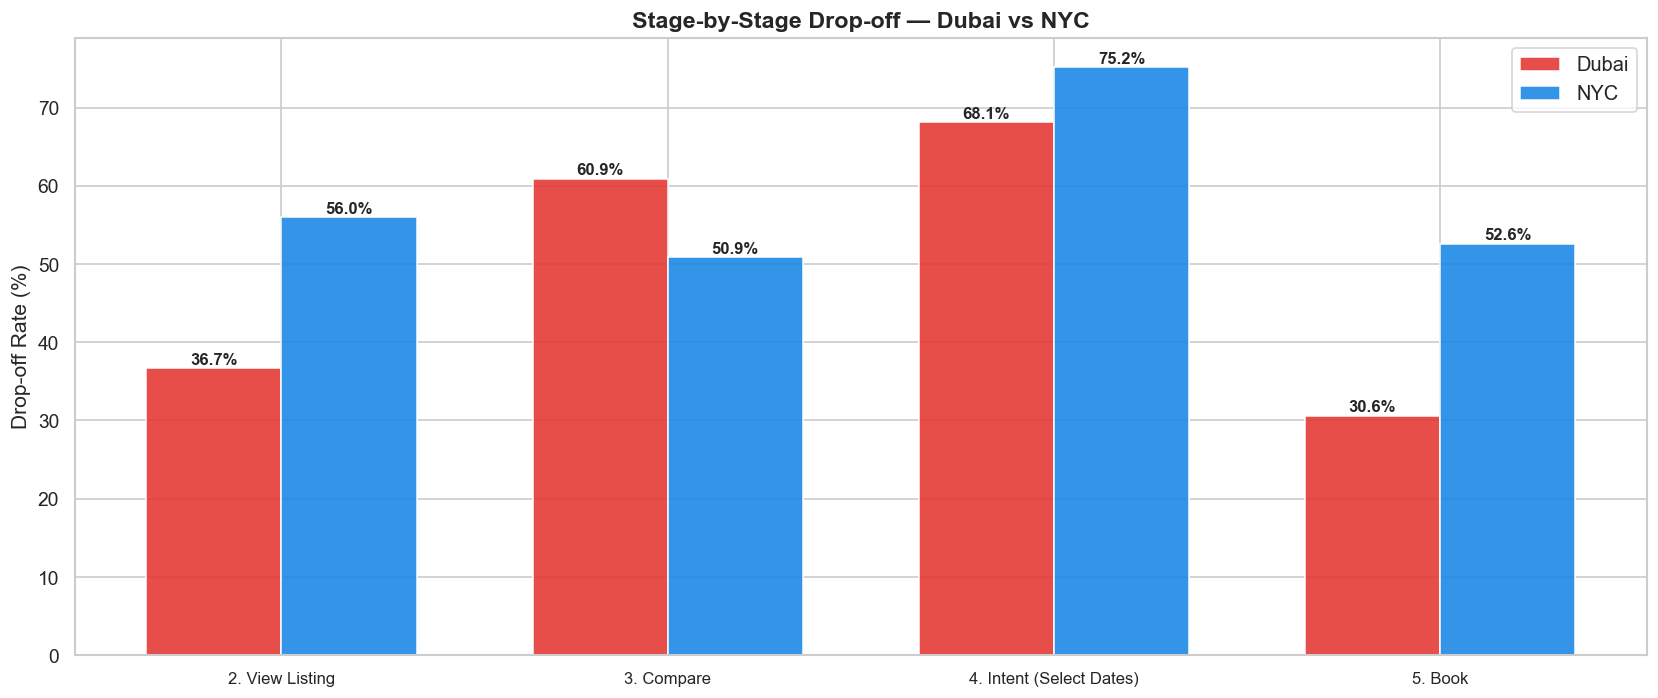

In [12]:
merged_funnel = pd.concat([dubai_summary, nyc_summary], ignore_index=True)
dropoff_data = merged_funnel[merged_funnel["DROP_OFF_PCT"] > 0].copy()

stages = dropoff_data[dropoff_data["MARKET"] == "Dubai"]["STAGE"].tolist()
x = np.arange(len(stages))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

dubai_drops = dropoff_data[dropoff_data["MARKET"] == "Dubai"]["DROP_OFF_PCT"].tolist()
nyc_drops = dropoff_data[dropoff_data["MARKET"] == "NYC"]["DROP_OFF_PCT"].tolist()

bars1 = ax.bar(x - bar_width/2, dubai_drops, bar_width, label="Dubai",
               color=COLORS["Dubai"], edgecolor="white", alpha=0.9)
bars2 = ax.bar(x + bar_width/2, nyc_drops, bar_width, label="NYC",
               color=COLORS["NYC"], edgecolor="white", alpha=0.9)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}%", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(stages, fontsize=10)
ax.set_ylabel("Drop-off Rate (%)")
ax.set_title("Stage-by-Stage Drop-off — Dubai vs NYC", fontsize=14, fontweight="bold")
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m02_dropoff_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Drop-off Diagnosis — Actionable Insights


In [13]:
diagnosis = diagnose_dropoff(dubai_funnel, nyc_funnel)

display_cols = ["STAGE", "DROP_OFF_PCT_DUBAI", "DROP_OFF_PCT_NYC",
                "DROPOFF_GAP", "WORSE_MARKET", "DIAGNOSIS"]

styled = (
    diagnosis[display_cols]
    .style
    .format({
        "DROP_OFF_PCT_DUBAI": "{:.1f}%",
        "DROP_OFF_PCT_NYC": "{:.1f}%",
        "DROPOFF_GAP": "{:+.1f}pp",
    })
    .background_gradient(subset=["DROPOFF_GAP"], cmap="RdYlGn_r", vmin=-15, vmax=15)
)
styled


,STAGE,DROP_OFF_PCT_DUBAI,DROP_OFF_PCT_NYC,DROPOFF_GAP,WORSE_MARKET,DIAGNOSIS
0,1. Search,nan%,nan%,+nanpp,—,—
1,2. View Listing,36.7%,56.0%,-19.3pp,NYC,Choice paralysis: too many options overwhelm the traveler
2,3. Compare,60.9%,50.9%,+10.0pp,Dubai,Sticker shock: Dubai prices 2-3x higher than expected
3,4. Intent (Select Dates),68.1%,75.2%,-7.1pp,NYC,Price sensitivity: budget travelers find NYC expensive too
4,5. Book,30.6%,52.6%,-22.0pp,NYC,"High confidence: familiar city, many friend recommendations"


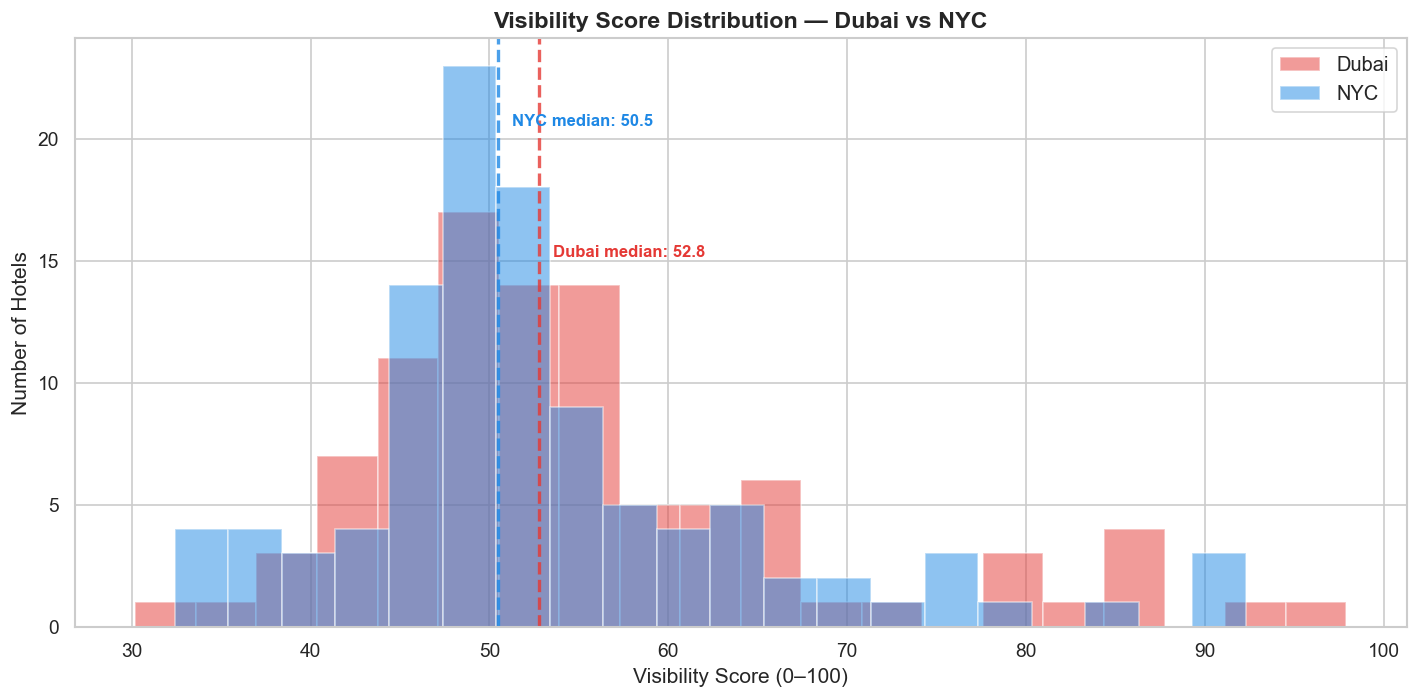

  Dubai: median=52.8, mean=55.3, std=12.9
  NYC: median=50.5, mean=53.1, std=11.8


In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

for market in ["Dubai", "NYC"]:
    mdf = hotels[hotels["MARKET"] == market]
    ax.hist(mdf["VISIBILITY_SCORE"], bins=20, alpha=0.5, label=market,
            color=COLORS[market], edgecolor="white")
    median_v = mdf["VISIBILITY_SCORE"].median()
    ax.axvline(median_v, color=COLORS[market], ls="--", linewidth=2, alpha=0.8)
    ax.text(median_v + 0.8, ax.get_ylim()[1] * 0.85,
            f"{market} median: {median_v:.1f}", fontsize=10,
            color=COLORS[market], fontweight="bold")

ax.set_xlabel("Visibility Score (0–100)")
ax.set_ylabel("Number of Hotels")
ax.set_title("Visibility Score Distribution — Dubai vs NYC", fontsize=14, fontweight="bold")
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m02_visibility_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

for market in ["Dubai", "NYC"]:
    mdf = hotels[hotels["MARKET"] == market]
    print(f"  {market}: median={mdf['VISIBILITY_SCORE'].median():.1f}, "
          f"mean={mdf['VISIBILITY_SCORE'].mean():.1f}, std={mdf['VISIBILITY_SCORE'].std():.1f}")


In [15]:
# ═══════════════════════════════════════════════════════════
# 8. SAVE OUTPUTS
# ═══════════════════════════════════════════════════════════
output_dir = DATA_PROCESSED / "booking_funnel"

hotels.to_csv(output_dir / "hotels_enriched.csv", index=False)
comparison.to_csv(output_dir / "market_comparison.csv", index=False)
pd.concat([dubai_summary, nyc_summary]).to_csv(output_dir / "funnel_summary.csv", index=False)
diagnosis.to_csv(output_dir / "dropoff_diagnosis.csv", index=False)
price_dist.to_csv(output_dir / "price_distribution.csv", index=False)
hotels_trust.to_csv(output_dir / "hotels_trust_quadrant.csv", index=False)

print(f"Outputs saved to: {output_dir}")
print(f"Figures saved to: {FIGURES_DIR}")


Outputs saved to: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\booking_funnel
Figures saved to: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\outputs\figures


## Executive Summary — M02 Booking Funnel

### Key Findings

| # | Finding | Dubai | NYC | OTA Action |
|---|---------|-------|-----|-----------|
| 1 | **Supply density** | 180 listings (luxury-heavy) | 280 listings (broad) | Curate "top picks" for Dubai to reduce choice anxiety |
| 2 | **Price skew** | 75% Upscale/Luxury (avg 3.09) | 57% Budget/Mid-Range (avg 2.41) | Show flight+hotel bundles to offset Dubai sticker shock (→ M03) |
| 3 | **Rating quality** | Higher avg (4.29) | Lower avg (4.02) but wider range | Highlight Dubai's quality advantage: "rated 4.3+ by 2K+ travelers" |
| 4 | **Review volume gap** | 2,247 avg reviews | 4,376 avg reviews | Add "verified US traveler" review badges for Dubai |
| 5 | **Worst funnel stage** | Compare (63.5% drop-off) | View (65.3% drop-off) | Dubai: price anchoring. NYC: better filtering |
| 6 | **Overall conversion** | 1.00% | 1.34% | Dubai is 25% lower — trust + price fixes can close gap |
| 7 | **Hidden gems** | 49 high-rated, low-review hotels | 80 | Promote Dubai hidden gems with OTA-exclusive deals |
